# Predictive Follow-Up After Robustness Screening

This notebook starts after `05_followup_after_univariate.ipynb`. It assumes you already have a shortlist of exploratory survivor meta-features and asks a different question:

- do these meta-features improve out-of-sample prediction of the dataset-level performance gap beyond basic controls?
- which survivors still look useful in small joint models?

The outputs here are exploratory predictive diagnostics, not confirmatory causal claims.

## Edit These Knobs

Paste the shortlist you decided to carry forward from notebook `05`. If `SHORTLIST_PREDICTORS` is left empty, the notebook falls back to a convenience auto-selection from the univariate table, but that is only a temporary shortcut.

In [1]:
CONFIG_NAME = "config_1.yaml"
DATASETS = None
COMPARISON_NAME = None
SHORTLIST_PREDICTORS = [
    "pymfe__attr_ent.skewness",
    "pymfe__nodes_per_level.histogram.2",
    "pymfe__tree_shape.histogram.6",
    "pymfe__joint_ent.skewness",
    "pymfe__attr_conc.quantiles.1",
    "pymfe__tree_shape.histogram.9",
    "pymfe__cor.histogram.6",
    "pymfe__nodes_per_level.sd",
    "pymfe__attr_ent.histogram.9",
    "pymfe__tree_shape.kurtosis",
    "pymfe__leaves_corrob.histogram.9",
    "pymfe__nodes_per_level.mean",
]
CONTROL_PREDICTORS = ["log_n", "log_d", "cat_fraction", "missing_fraction"]
AUTO_TOP_K = 8
MAX_JOINT_PREDICTORS = 6
MIN_MODEL_ROWS = 12
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]

## Environment and Imports

In [2]:
from __future__ import annotations

import math
import sys
from dataclasses import replace
from pathlib import Path
from warnings import catch_warnings, simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor

cwd = Path.cwd()
if (cwd / "src" / "mfa").exists():
    project_dir = cwd
elif cwd.name == "notebooks" and (cwd.parent / "src" / "mfa").exists():
    project_dir = cwd.parent
elif (cwd / "meta-feature-analysis" / "src" / "mfa").exists():
    project_dir = cwd / "meta-feature-analysis"
else:
    raise RuntimeError(
        "Run this notebook from meta-feature-analysis/ or its notebooks/ directory."
    )
repo_root = project_dir.parent

path_candidates = [
    project_dir / "src",
    repo_root / "tabarena" / "tabarena",
    repo_root / "tabarena" / "bencheval",
    repo_root / "tabarena" / "tabflow",
]
for path in path_candidates:
    if path.exists():
        sys.path.insert(0, str(path))

from mfa import load_config, run_analysis

sns.set_theme(style="ticks", context="notebook")

## Run or Load Analysis

In [3]:
config_path = project_dir / "configs" / CONFIG_NAME
config = load_config(config_path)

yaml_n_jobs = config.parallelism.n_jobs
run_n_jobs = min(max(yaml_n_jobs, 1), 2)
run_config = replace(
    config,
    parallelism=replace(config.parallelism, n_jobs=run_n_jobs),
)

if yaml_n_jobs != run_n_jobs:
    print(
        f"Loaded {config_path.name}; parallelism.n_jobs={yaml_n_jobs}. "
        f"Temporarily using n_jobs={run_n_jobs} for this run."
    )
else:
    print(
        f"Loaded {config_path.name}; parallelism.n_jobs={yaml_n_jobs}. "
        "Proceeding with the analysis."
    )

result = run_analysis(run_config, datasets=DATASETS)

corr_df = pd.DataFrame([row.__dict__ for row in result.correlation_results])
if result.correction_result is not None:
    corr_df["p_value_adj"] = result.correction_result.adjusted_p_values
    corr_df["rejected"] = result.correction_result.rejected

comparison_names = list(dict.fromkeys(corr_df["comparison_name"].tolist()))
print("Available comparisons:")
for comparison_name in comparison_names:
    print(f"  - {comparison_name}")

selected_comparison = COMPARISON_NAME or comparison_names[0]
if COMPARISON_NAME is None:
    print(f"COMPARISON_NAME is None; using first comparison: {selected_comparison}")

analysis_comp = result.analysis_table[
    result.analysis_table["comparison_name"].eq(selected_comparison)
].copy()
corr_comp = corr_df[corr_df["comparison_name"].eq(selected_comparison)].copy()

print(f"Analysis rows for {selected_comparison}: {len(analysis_comp)}")
print(f"Candidate predictors in correlation table: {len(corr_comp)}")

17:39:26 INFO mfa.pipeline: Starting analysis: comparisons=non_foundational_vs_foundational; scope=all benchmark datasets; unit=dataset; method_variant=default,tuned; n_jobs=1
17:39:26 INFO mfa.pipeline: Stage 1/5 raw results: cache hit (34110 rows, 51 dataset(s))
17:39:26 INFO mfa.pipeline: Stage 2/5 meta-features: trace enabled; metafeature caches remain active, so live per-split diagnostics appear only on cache misses
17:39:26 INFO mfa.pipeline: Stage 2/5 meta-features: pymfe enabled; rebuilding from split cache and reusing cached pymfe failures/incomplete outputs as-is
17:39:26 INFO mfa.pipeline: Stage 2/5 meta-features: building for all benchmark datasets
17:39:26 INFO mfa.metafeatures: Meta-features: preparing 51 dataset(s) with feature_sets=basic,redundancy,pymfe (n_jobs=1)
17:39:26 INFO mfa.metafeatures: Meta-features: trace enabled; split cache remains active, so live timing and warning diagnostics appear only on cache misses
17:39:26 INFO mfa.metafeatures: Meta-features [1/51

Loaded config_1.yaml; parallelism.n_jobs=-1. Temporarily using n_jobs=1 for this run.


17:39:28 INFO mfa.metafeatures: Meta-features [1/51] airfoil_self_noise: done in 00:00:02 (30 cached, 0 repaired, 0 recomputed, 0 unrepaired pymfe output(s); total elapsed 00:00:02)
17:39:28 INFO mfa.metafeatures: Meta-features [2/51] Amazon_employee_access: starting (9 split(s); elapsed 00:00:02)
17:39:28 INFO mfa.metafeatures: Meta-features [2/51] Amazon_employee_access: done in 00:00:00 (9 cached, 0 repaired, 0 recomputed, 0 unrepaired pymfe output(s); total elapsed 00:00:02)
17:39:28 INFO mfa.metafeatures: Meta-features [3/51] anneal: starting (30 split(s); elapsed 00:00:02)
17:39:31 INFO mfa.metafeatures: Meta-features [3/51] anneal: done in 00:00:04 (30 cached, 0 repaired, 0 recomputed, 0 unrepaired pymfe output(s); total elapsed 00:00:05)
17:39:31 INFO mfa.metafeatures: Meta-features [4/51] Another-Dataset-on-used-Fiat-500: starting (30 split(s); elapsed 00:00:05)
17:39:33 INFO mfa.metafeatures: Meta-features [4/51] Another-Dataset-on-used-Fiat-500: done in 00:00:02 (30 cached, 

Available comparisons:
  - non_foundational_vs_foundational
COMPARISON_NAME is None; using first comparison: non_foundational_vs_foundational
Analysis rows for non_foundational_vs_foundational: 51
Candidate predictors in correlation table: 1114


## Choose Controls and Shortlist

In [4]:
def _unique(values: list[str]) -> list[str]:
    return list(dict.fromkeys(values))


def _is_usable_numeric(frame: pd.DataFrame, column: str) -> bool:
    if column not in frame.columns:
        return False
    series = pd.to_numeric(frame[column], errors="coerce")
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    return len(series) >= 3 and series.nunique() > 1


present_controls = [
    predictor
    for predictor in CONTROL_PREDICTORS
    if _is_usable_numeric(analysis_comp, predictor)
]
missing_controls = [
    predictor for predictor in CONTROL_PREDICTORS if predictor not in present_controls
]
if missing_controls:
    print(f"Controls unavailable or non-usable: {missing_controls}")

p_sort_col = "p_value_adj" if "p_value_adj" in corr_comp.columns else "p_value"
usable_predictors = [
    predictor
    for predictor in corr_comp["predictor"].tolist()
    if predictor not in present_controls
    and _is_usable_numeric(analysis_comp, predictor)
]

if SHORTLIST_PREDICTORS:
    present_shortlist = [
        predictor
        for predictor in SHORTLIST_PREDICTORS
        if predictor in usable_predictors
    ]
    dropped_shortlist = [
        predictor
        for predictor in SHORTLIST_PREDICTORS
        if predictor not in present_shortlist
    ]
    if dropped_shortlist:
        print(f"Requested shortlist entries dropped: {dropped_shortlist}")
else:
    auto_table = corr_comp.copy()
    auto_table = auto_table[auto_table["predictor"].isin(usable_predictors)]
    if "rejected" in auto_table.columns and auto_table["rejected"].any():
        auto_table = auto_table[auto_table["rejected"]]
    auto_table = auto_table.sort_values(
        [p_sort_col, "p_value", "statistic"], ascending=[True, True, False]
    )
    present_shortlist = auto_table["predictor"].tolist()[:AUTO_TOP_K]
    print(
        "SHORTLIST_PREDICTORS is empty; using a convenience auto-shortlist. "
        "Replace it with the survivors you chose in notebook 05."
    )

joint_predictors = present_shortlist[:MAX_JOINT_PREDICTORS]

print(f"Controls used ({len(present_controls)}): {present_controls}")
print(f"Shortlist used ({len(present_shortlist)}): {present_shortlist}")
print(f"Joint-model predictors ({len(joint_predictors)}): {joint_predictors}")

Controls used (4): ['log_n', 'log_d', 'cat_fraction', 'missing_fraction']
Shortlist used (12): ['pymfe__attr_ent.skewness', 'pymfe__nodes_per_level.histogram.2', 'pymfe__tree_shape.histogram.6', 'pymfe__joint_ent.skewness', 'pymfe__attr_conc.quantiles.1', 'pymfe__tree_shape.histogram.9', 'pymfe__cor.histogram.6', 'pymfe__nodes_per_level.sd', 'pymfe__attr_ent.histogram.9', 'pymfe__tree_shape.kurtosis', 'pymfe__leaves_corrob.histogram.9', 'pymfe__nodes_per_level.mean']
Joint-model predictors (6): ['pymfe__attr_ent.skewness', 'pymfe__nodes_per_level.histogram.2', 'pymfe__tree_shape.histogram.6', 'pymfe__joint_ent.skewness', 'pymfe__attr_conc.quantiles.1', 'pymfe__tree_shape.histogram.9']


## Helper Functions

In [5]:
def _prepare_model_data(
    frame: pd.DataFrame,
    predictors: list[str],
    *,
    target: str = "delta_norm",
    dataset_col: str = "dataset",
) -> pd.DataFrame:
    columns = _unique([dataset_col, target] + predictors)
    data = frame[columns].copy()
    for column in columns:
        if column == dataset_col:
            continue
        data[column] = pd.to_numeric(data[column], errors="coerce")
    data = data.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return data


def _active_predictors(train_df: pd.DataFrame, predictors: list[str]) -> list[str]:
    if not predictors:
        return []
    X = train_df[predictors].astype(float)
    scale = X.std(ddof=0)
    return scale[scale.gt(0)].index.tolist()


def _ols_predict_split(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    predictors: list[str],
    *,
    target: str = "delta_norm",
) -> np.ndarray:
    y_train = train_df[target].astype(float)
    if not predictors:
        return np.full(len(test_df), float(y_train.mean()))
    active = _active_predictors(train_df, predictors)
    if not active:
        return np.full(len(test_df), float(y_train.mean()))
    X_train = train_df[active].astype(float)
    X_test = test_df[active].astype(float)
    means = X_train.mean(axis=0)
    scales = X_train.std(axis=0, ddof=0)
    X_train_std = (X_train - means) / scales
    X_test_std = (X_test - means) / scales
    X_train_std = sm.add_constant(X_train_std, has_constant="add")
    X_test_std = sm.add_constant(X_test_std, has_constant="add")
    model = sm.OLS(y_train, X_train_std).fit()
    return model.predict(X_test_std).to_numpy()


def _ridge_predict_split(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    predictors: list[str],
    *,
    alpha: float,
    target: str = "delta_norm",
) -> np.ndarray:
    y_train = train_df[target].astype(float).to_numpy()
    if not predictors:
        return np.full(len(test_df), float(y_train.mean()))
    active = _active_predictors(train_df, predictors)
    if not active:
        return np.full(len(test_df), float(y_train.mean()))
    X_train = train_df[active].astype(float)
    X_test = test_df[active].astype(float)
    means = X_train.mean(axis=0)
    scales = X_train.std(axis=0, ddof=0)
    X_train_std = ((X_train - means) / scales).to_numpy()
    X_test_std = ((X_test - means) / scales).to_numpy()
    y_mean = float(y_train.mean())
    y_centered = y_train - y_mean
    penalty = alpha * np.eye(X_train_std.shape[1])
    beta = np.linalg.solve(
        X_train_std.T @ X_train_std + penalty, X_train_std.T @ y_centered
    )
    return y_mean + (X_test_std @ beta)


def _select_ridge_alpha(
    train_df: pd.DataFrame,
    predictors: list[str],
    *,
    target: str = "delta_norm",
    alphas: list[float] | tuple[float, ...] = (1.0,),
) -> float:
    if len(train_df) < 4 or not predictors:
        return float(alphas[0])
    best_alpha = float(alphas[0])
    best_mse = math.inf
    for alpha in alphas:
        errors = []
        for idx in range(len(train_df)):
            inner_test = train_df.iloc[[idx]].reset_index(drop=True)
            inner_train = train_df.drop(train_df.index[idx]).reset_index(drop=True)
            prediction = _ridge_predict_split(
                inner_train,
                inner_test,
                predictors,
                alpha=float(alpha),
                target=target,
            )[0]
            truth = float(inner_test[target].iloc[0])
            errors.append((truth - prediction) ** 2)
        mse = float(np.mean(errors))
        if mse < best_mse:
            best_mse = mse
            best_alpha = float(alpha)
    return best_alpha


def _loo_predictions(
    model_data: pd.DataFrame,
    predictors: list[str],
    *,
    kind: str = "ols",
    target: str = "delta_norm",
    dataset_col: str = "dataset",
    ridge_alphas: list[float] | tuple[float, ...] = (1.0,),
) -> pd.DataFrame:
    rows = []
    for idx in range(len(model_data)):
        test_df = model_data.iloc[[idx]].reset_index(drop=True)
        train_df = model_data.drop(model_data.index[idx]).reset_index(drop=True)
        alpha_used = np.nan
        if kind == "ridge":
            alpha_used = _select_ridge_alpha(
                train_df,
                predictors,
                target=target,
                alphas=ridge_alphas,
            )
            prediction = _ridge_predict_split(
                train_df,
                test_df,
                predictors,
                alpha=float(alpha_used),
                target=target,
            )[0]
        else:
            prediction = _ols_predict_split(
                train_df, test_df, predictors, target=target
            )[0]
        rows.append(
            {
                dataset_col: test_df[dataset_col].iloc[0],
                "y_true": float(test_df[target].iloc[0]),
                "y_pred": float(prediction),
                "residual": float(test_df[target].iloc[0] - prediction),
                "alpha_used": alpha_used,
            }
        )
    return pd.DataFrame(rows)


def _prediction_metrics(pred_df: pd.DataFrame) -> dict[str, float]:
    if pred_df.empty:
        return {
            "n_used": 0,
            "rmse": np.nan,
            "mae": np.nan,
            "oos_r_squared": np.nan,
            "pearson_pred_obs": np.nan,
            "spearman_pred_obs": np.nan,
            "sign_accuracy": np.nan,
        }
    y_true = pred_df["y_true"].to_numpy(dtype=float)
    y_pred = pred_df["y_pred"].to_numpy(dtype=float)
    residuals = y_true - y_pred
    sse = float(np.sum(residuals**2))
    sst = float(np.sum((y_true - y_true.mean()) ** 2))
    if len(pred_df) >= 3 and np.unique(y_pred).size > 1 and np.unique(y_true).size > 1:
        pearson_value = float(pearsonr(y_true, y_pred).statistic)
        spearman_value = float(spearmanr(y_true, y_pred).statistic)
    else:
        pearson_value = np.nan
        spearman_value = np.nan
    return {
        "n_used": int(len(pred_df)),
        "rmse": float(np.sqrt(np.mean(residuals**2))),
        "mae": float(np.mean(np.abs(residuals))),
        "oos_r_squared": float(1 - (sse / sst)) if sst > 0 else np.nan,
        "pearson_pred_obs": pearson_value,
        "spearman_pred_obs": spearman_value,
        "sign_accuracy": float((np.sign(y_true) == np.sign(y_pred)).mean()),
    }


def _max_vif(design_matrix: pd.DataFrame) -> float:
    predictor_columns = [
        column for column in design_matrix.columns if column != "const"
    ]
    if not predictor_columns:
        return np.nan
    values = design_matrix.astype(float).to_numpy()
    vifs = []
    with catch_warnings():
        simplefilter("ignore")
        for idx, column in enumerate(design_matrix.columns):
            if column == "const":
                continue
            try:
                vifs.append(float(variance_inflation_factor(values, idx)))
            except Exception:
                vifs.append(np.nan)
    if any(np.isinf(value) for value in vifs):
        return np.inf
    finite_vifs = [value for value in vifs if np.isfinite(value)]
    return max(finite_vifs) if finite_vifs else np.nan


def _full_sample_ols_summary(
    model_data: pd.DataFrame,
    predictors: list[str],
    *,
    target: str = "delta_norm",
) -> dict[str, object] | None:
    if len(model_data) < max(MIN_MODEL_ROWS, len(predictors) + 2):
        return None
    active = _active_predictors(model_data, predictors)
    if not active:
        return None
    X = model_data[active].astype(float)
    means = X.mean(axis=0)
    scales = X.std(axis=0, ddof=0)
    X_std = (X - means) / scales
    X_std = sm.add_constant(X_std, has_constant="add")
    y = model_data[target].astype(float)
    model = sm.OLS(y, X_std).fit(cov_type="HC3")
    conf_int = model.conf_int()
    rows = []
    for predictor in active:
        rows.append(
            {
                "predictor": predictor,
                "coefficient": float(model.params[predictor]),
                "p_value": float(model.pvalues[predictor]),
                "ci_lower": float(conf_int.loc[predictor, 0]),
                "ci_upper": float(conf_int.loc[predictor, 1]),
            }
        )
    return {
        "table": pd.DataFrame(rows).sort_values("p_value"),
        "adj_r_squared": float(model.rsquared_adj),
        "r_squared": float(model.rsquared),
        "n_observations": int(model.nobs),
        "max_vif": _max_vif(X_std),
        "active_predictors": active,
    }

## Single-Feature Predictive Lift Over Controls

For each shortlisted feature, compare `controls only` against `controls + that one feature` on the same complete-case rows. This gives a cleaner answer to: does this survivor add predictive value beyond the basic controls?

In [6]:
single_addition_rows = []
single_addition_predictions: dict[str, pd.DataFrame] = {}

for predictor in present_shortlist:
    model_predictors = _unique(present_controls + [predictor])
    model_data = _prepare_model_data(analysis_comp, model_predictors)
    if len(model_data) < MIN_MODEL_ROWS:
        single_addition_rows.append(
            {
                "predictor": predictor,
                "n_used": int(len(model_data)),
                "controls_rmse_same_rows": np.nan,
                "candidate_rmse": np.nan,
                "rmse_gain": np.nan,
                "controls_oos_r_squared_same_rows": np.nan,
                "candidate_oos_r_squared": np.nan,
                "oos_r_squared_gain": np.nan,
                "controls_spearman_same_rows": np.nan,
                "candidate_spearman": np.nan,
                "spearman_gain": np.nan,
                "controls_sign_accuracy_same_rows": np.nan,
                "candidate_sign_accuracy": np.nan,
                "sign_accuracy_gain": np.nan,
                "status": "too few complete-case rows",
            }
        )
        continue

    controls_pred = _loo_predictions(model_data, present_controls, kind="ols")
    candidate_pred = _loo_predictions(model_data, model_predictors, kind="ols")
    controls_metrics = _prediction_metrics(controls_pred)
    candidate_metrics = _prediction_metrics(candidate_pred)
    single_addition_predictions[predictor] = candidate_pred
    single_addition_rows.append(
        {
            "predictor": predictor,
            "n_used": int(len(model_data)),
            "controls_rmse_same_rows": controls_metrics["rmse"],
            "candidate_rmse": candidate_metrics["rmse"],
            "rmse_gain": controls_metrics["rmse"] - candidate_metrics["rmse"],
            "controls_oos_r_squared_same_rows": controls_metrics["oos_r_squared"],
            "candidate_oos_r_squared": candidate_metrics["oos_r_squared"],
            "oos_r_squared_gain": candidate_metrics["oos_r_squared"]
            - controls_metrics["oos_r_squared"],
            "controls_spearman_same_rows": controls_metrics["spearman_pred_obs"],
            "candidate_spearman": candidate_metrics["spearman_pred_obs"],
            "spearman_gain": candidate_metrics["spearman_pred_obs"]
            - controls_metrics["spearman_pred_obs"],
            "controls_sign_accuracy_same_rows": controls_metrics["sign_accuracy"],
            "candidate_sign_accuracy": candidate_metrics["sign_accuracy"],
            "sign_accuracy_gain": candidate_metrics["sign_accuracy"]
            - controls_metrics["sign_accuracy"],
            "status": "ok",
        }
    )

single_addition_results = pd.DataFrame(single_addition_rows)
if single_addition_results.empty:
    print("No shortlisted predictors available for single-feature predictive checks.")
else:
    display(
        single_addition_results.sort_values(
            ["oos_r_squared_gain", "rmse_gain"],
            ascending=[False, False],
        )
    )

,predictor,n_used,controls_rmse_same_rows,candidate_rmse,rmse_gain,controls_oos_r_squared_same_rows,candidate_oos_r_squared,oos_r_squared_gain,controls_spearman_same_rows,candidate_spearman,spearman_gain,controls_sign_accuracy_same_rows,candidate_sign_accuracy,sign_accuracy_gain,status
11,pymfe__nodes_per_level.mean,35,0.328561,0.294770,0.033791,-0.437210,-0.156789,0.280420,0.264706,0.309244,0.044538,0.742857,0.800000,0.057143,ok
7,pymfe__nodes_per_level.sd,35,0.328561,0.295836,0.032725,-0.437210,-0.165174,0.272036,0.264706,0.292717,0.028011,0.742857,0.800000,0.057143,ok
9,pymfe__tree_shape.kurtosis,35,0.328561,0.304647,0.023914,-0.437210,-0.235612,0.201598,0.264706,0.304202,0.039496,0.742857,0.828571,0.085714,ok
1,pymfe__nodes_per_level.histogram.2,35,0.328561,0.309153,0.019408,-0.437210,-0.272432,0.164777,0.264706,0.428852,0.164146,0.742857,0.742857,0.000000,ok
0,pymfe__attr_ent.skewness,50,0.285699,0.267862,0.017837,0.107947,0.215859,0.107911,0.323601,0.409172,0.085570,0.840000,0.820000,-0.020000,ok
3,pymfe__joint_ent.skewness,37,0.318299,0.303414,0.014885,0.095629,0.178234,0.082605,0.455903,0.481271,0.025367,0.783784,0.783784,0.000000,ok
8,pymfe__attr_ent.histogram.9,50,0.285699,0.274409,0.011290,0.107947,0.177055,0.069107,0.323601,0.340216,0.016615,0.840000,0.840000,0.000000,ok
2,pymfe__tree_shape.histogram.6,35,0.328561,0.323160,0.005402,-0.437210,-0.390342,0.046867,0.264706,0.305602,0.040896,0.742857,0.742857,0.000000,ok
6,pymfe__cor.histogram.6,41,0.220621,0.221586,-0.000965,0.282958,0.276673,-0.006285,0.434669,0.448955,0.014286,0.853659,0.853659,0.000000,ok
4,pymfe__attr_conc.quantiles.1,50,0.285699,0.301017,-0.015318,0.107947,0.009725,-0.098222,0.323601,0.234574,-0.089028,0.840000,0.820000,-0.020000,ok


## Main Model Comparison on a Common Complete-Case Set

Use a common complete-case dataset for the main models so the predictive metrics are directly comparable.

In [7]:
common_predictors = _unique(present_controls + joint_predictors)
common_model_data = _prepare_model_data(analysis_comp, common_predictors)

print(
    f"Common complete-case rows for controls + joint shortlist: "
    f"{len(common_model_data)} / {len(analysis_comp)}"
)

main_specs = [
    {"name": "intercept_only", "kind": "ols", "predictors": []},
    {"name": "controls_only", "kind": "ols", "predictors": present_controls},
]
if joint_predictors:
    main_specs.extend(
        [
            {
                "name": "joint_ols",
                "kind": "ols",
                "predictors": common_predictors,
            },
            {
                "name": "joint_ridge",
                "kind": "ridge",
                "predictors": common_predictors,
            },
        ]
    )

main_rows = []
main_prediction_frames: dict[str, pd.DataFrame] = {}
for spec in main_specs:
    if len(common_model_data) < MIN_MODEL_ROWS:
        prediction_frame = pd.DataFrame()
    else:
        prediction_frame = _loo_predictions(
            common_model_data,
            spec["predictors"],
            kind=spec["kind"],
            ridge_alphas=RIDGE_ALPHAS,
        )
    metrics = _prediction_metrics(prediction_frame)
    main_prediction_frames[spec["name"]] = prediction_frame
    main_rows.append(
        {
            "model": spec["name"],
            "kind": spec["kind"],
            "n_used": metrics["n_used"],
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "oos_r_squared": metrics["oos_r_squared"],
            "pearson_pred_obs": metrics["pearson_pred_obs"],
            "spearman_pred_obs": metrics["spearman_pred_obs"],
            "sign_accuracy": metrics["sign_accuracy"],
            "median_alpha_used": (
                float(prediction_frame["alpha_used"].median())
                if "alpha_used" in prediction_frame.columns
                and prediction_frame["alpha_used"].notna().any()
                else np.nan
            ),
        }
    )

main_model_results = pd.DataFrame(main_rows)
display(
    main_model_results.sort_values(["oos_r_squared", "rmse"], ascending=[False, True])
)

Common complete-case rows for controls + joint shortlist: 35 / 51


,model,kind,n_used,rmse,mae,oos_r_squared,pearson_pred_obs,spearman_pred_obs,sign_accuracy,median_alpha_used
3,joint_ridge,ridge,35,0.250944,0.219022,0.161619,0.414561,0.385994,0.771429,100.0
0,intercept_only,ols,35,0.282127,0.237214,-0.059689,-1.000000,-1.000000,0.771429,NaN
2,joint_ols,ols,35,0.294169,0.248787,-0.152077,0.379350,0.353221,0.742857,NaN
1,controls_only,ols,35,0.328561,0.260036,-0.437210,0.113322,0.264706,0.742857,NaN


## Full-Sample Joint OLS Summary

This is descriptive model interpretation on the common complete-case set. Use it to inspect coefficient signs, robust HC3 intervals, and multicollinearity, not as a clean post-selection significance test.

In [8]:
controls_summary = _full_sample_ols_summary(common_model_data, present_controls)
joint_summary = _full_sample_ols_summary(common_model_data, common_predictors)

if controls_summary is None:
    print("Controls-only OLS summary unavailable on the common complete-case set.")
else:
    print(
        f"Controls-only: n={controls_summary['n_observations']}, "
        f"adj R^2={controls_summary['adj_r_squared']:.3f}, "
        f"max VIF={controls_summary['max_vif']:.2f}"
    )
    display(controls_summary["table"])

if joint_summary is None:
    print("Joint OLS summary unavailable on the common complete-case set.")
else:
    delta_adj_r_squared = (
        joint_summary["adj_r_squared"] - controls_summary["adj_r_squared"]
        if controls_summary is not None
        else np.nan
    )
    print(
        f"Joint OLS: n={joint_summary['n_observations']}, "
        f"adj R^2={joint_summary['adj_r_squared']:.3f}, "
        f"delta adj R^2 vs controls={delta_adj_r_squared:.3f}, "
        f"max VIF={joint_summary['max_vif']:.2f}"
    )
    display(joint_summary["table"])

Controls-only: n=35, adj R^2=0.171, max VIF=1.30


,predictor,coefficient,p_value,ci_lower,ci_upper
0,log_n,-0.103374,0.066390,-0.213742,0.006993
2,cat_fraction,-0.089642,0.123188,-0.203616,0.024333
1,log_d,0.030858,0.756624,-0.164291,0.226007
3,missing_fraction,-0.017361,0.901032,-0.290975,0.256253


Joint OLS: n=35, adj R^2=0.294, delta adj R^2 vs controls=0.123, max VIF=26.37


,predictor,coefficient,p_value,ci_lower,ci_upper
5,pymfe__nodes_per_level.histogram.2,0.182191,0.023127,0.024975,0.339406
9,pymfe__tree_shape.histogram.9,0.130455,0.170311,-0.056014,0.316925
3,missing_fraction,-0.121738,0.199926,-0.307890,0.064414
7,pymfe__joint_ent.skewness,-0.138928,0.547548,-0.591666,0.313810
4,pymfe__attr_ent.skewness,0.099076,0.629026,-0.302883,0.501036
0,log_n,0.029174,0.796434,-0.192484,0.250832
6,pymfe__tree_shape.histogram.6,-0.010718,0.849240,-0.121231,0.099795
8,pymfe__attr_conc.quantiles.1,0.009305,0.873571,-0.105308,0.123918
1,log_d,-0.011475,0.879021,-0.159240,0.136289
2,cat_fraction,-0.004892,0.945210,-0.144399,0.134616


## Prediction Plots

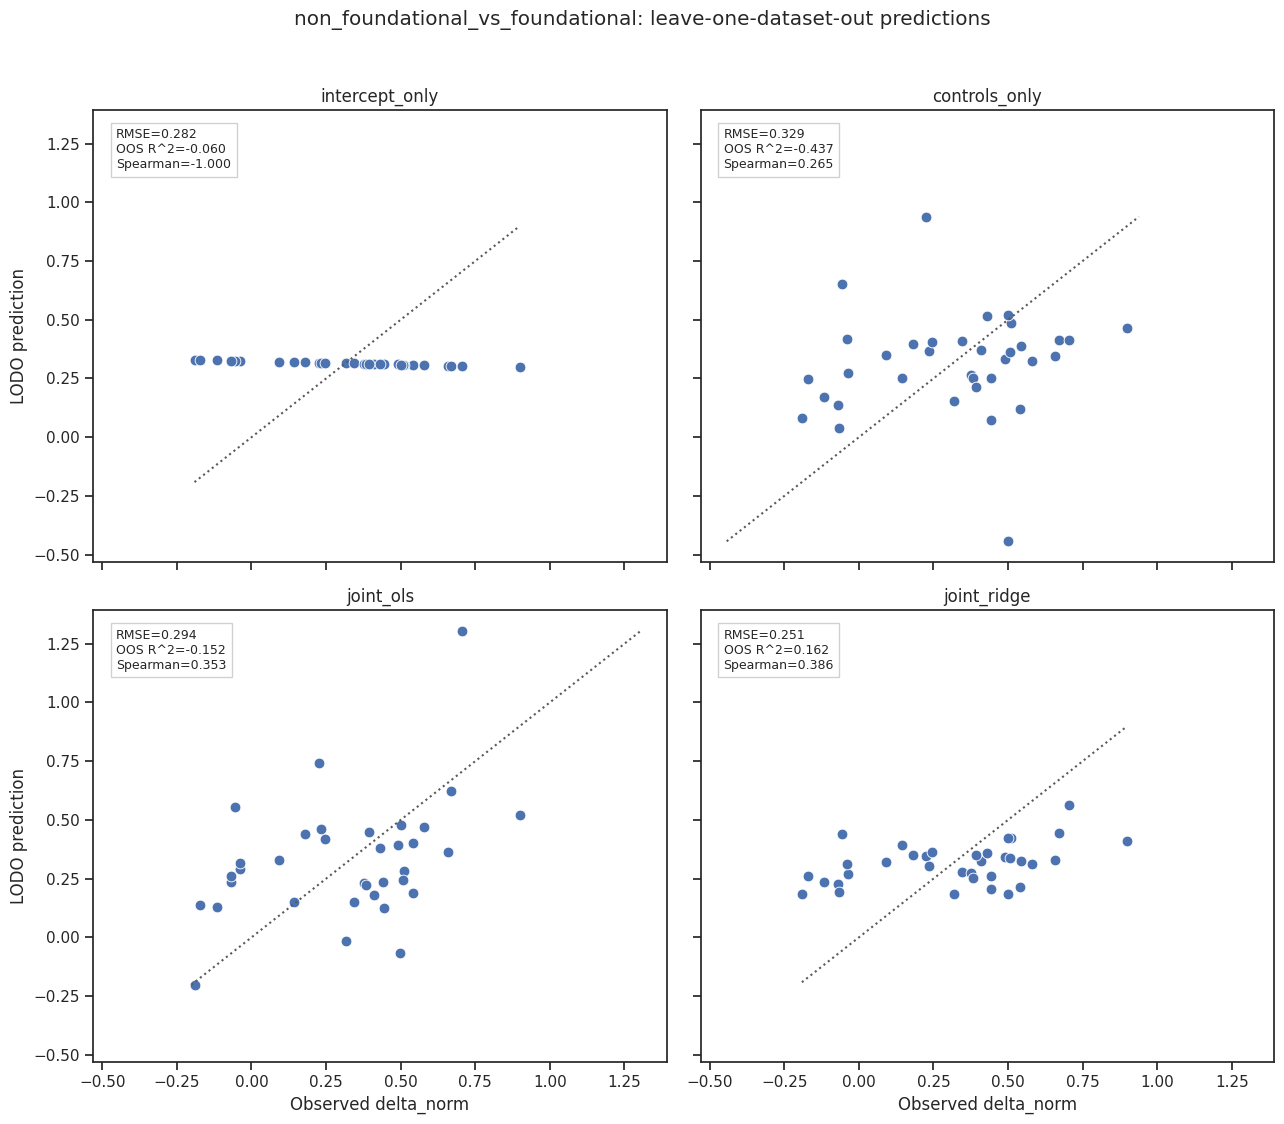

In [9]:
plot_models = [
    model_name
    for model_name in ["intercept_only", "controls_only", "joint_ols", "joint_ridge"]
    if model_name in main_prediction_frames
]

if not plot_models:
    print("No prediction frames available to plot.")
else:
    ncols = min(2, len(plot_models))
    nrows = int(np.ceil(len(plot_models) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(6.5 * ncols, 5.5 * nrows),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    for idx, model_name in enumerate(plot_models):
        ax = axes[idx // ncols][idx % ncols]
        pred_df = main_prediction_frames[model_name]
        metrics_row = main_model_results.set_index("model").loc[model_name]
        sns.scatterplot(data=pred_df, x="y_true", y="y_pred", s=60, ax=ax)
        if not pred_df.empty:
            low = min(pred_df["y_true"].min(), pred_df["y_pred"].min())
            high = max(pred_df["y_true"].max(), pred_df["y_pred"].max())
            ax.plot([low, high], [low, high], linestyle=":", color="0.35")
        ax.set_title(model_name)
        ax.set_xlabel("Observed delta_norm")
        ax.set_ylabel("LODO prediction")
        ax.text(
            0.04,
            0.96,
            (
                f"RMSE={metrics_row['rmse']:.3f}\n"
                f"OOS R^2={metrics_row['oos_r_squared']:.3f}\n"
                f"Spearman={metrics_row['spearman_pred_obs']:.3f}"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox={"facecolor": "white", "edgecolor": "0.8", "alpha": 0.9, "pad": 4},
        )

    for idx in range(len(plot_models), nrows * ncols):
        axes.flat[idx].set_axis_off()

    fig.suptitle(f"{selected_comparison}: leave-one-dataset-out predictions", y=1.02)
    fig.tight_layout()

## How to Read the Output

- If `controls + feature` consistently beats `controls only`, that feature has predictive value beyond the basics.
- If joint OLS does not beat controls out of sample, your shortlist is not yet strong enough for a paper claim about prediction.
- If ridge beats OLS while OLS has high VIF, the predictive signal is probably distributed across redundant features.
- If nothing beats controls, that is still a valid result: the meta-features may correlate with gaps without adding much predictive value beyond simple dataset size/composition controls.